In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [2]:
raw_dir = Path("../data/raw")

files = [
    raw_dir / "flights_2025_01_departure.csv",
    raw_dir / "flights_2025_02_departure.csv",
    raw_dir / "flights_2025_03_departure.csv",
]

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    print(file.name, temp.shape)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

flights_2025_01_departure.csv (539747, 32)
flights_2025_02_departure.csv (504884, 32)
flights_2025_03_departure.csv (600872, 32)


(1645503, 32)

In [3]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(1611046, 32)

In [4]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "DEP_DELAY_GROUP",
    "TAXI_OUT",
    "WHEELS_OFF"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

In [5]:
train_data = completed[completed["MONTH"] == 1].copy()
val_data = completed[completed["MONTH"] == 2].copy()
test_data = completed[completed["MONTH"] == 3].copy()

X_train = train_data[features]
y_train = train_data[target].astype(int)

X_val = val_data[features]
y_val = val_data[target].astype(int)

X_test = test_data[features]
y_test = test_data[target].astype(int)

X_train.shape, X_val.shape, X_test.shape

((522269, 18), (496476, 18), (592301, 18))

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [7]:
hgb_departure_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_departure_model.fit(X_train, y_train)

test_probs = hgb_departure_model.predict_proba(X_test)[:, 1]

In [8]:
best_threshold = 0.41

test_preds = (test_probs >= best_threshold).astype(int)

print("Departure-Delay Model: March Test")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("F1:", f1_score(y_test, test_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

print()
print(classification_report(y_test, test_preds, zero_division=0))

Departure-Delay Model: March Test
Threshold: 0.41
Accuracy: 0.9448591172393767
Precision: 0.9062981228436093
Recall: 0.8013858007135839
F1: 0.8506192941693043
ROC-AUC: 0.9628379577861427

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    476267
           1       0.91      0.80      0.85    116034

    accuracy                           0.94    592301
   macro avg       0.93      0.89      0.91    592301
weighted avg       0.94      0.94      0.94    592301



In [9]:
sample_size = 50000

X_test_sample = X_test.sample(
    n=sample_size,
    random_state=42
)

y_test_sample = y_test.loc[X_test_sample.index]

X_test_sample.shape, y_test_sample.shape

((50000, 18), (50000,))

In [10]:
perm_result = permutation_importance(
    hgb_departure_model,
    X_test_sample,
    y_test_sample,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

importance_df

,feature,importance_mean,importance_std
7,DEP_DELAY,0.590152,0.004666
11,TAXI_OUT,0.100246,0.002994
5,DISTANCE,0.003831,0.000965
13,OP_UNIQUE_CARRIER,0.002453,0.000883
12,WHEELS_OFF,0.001806,0.000436
14,ORIGIN,0.001375,0.000412
17,ARR_TIME_BLK,0.000870,0.000248
2,DAY_OF_WEEK,0.000480,0.000295
1,DAY_OF_MONTH,0.000289,0.000083
10,DEP_DELAY_GROUP,0.000069,0.000151


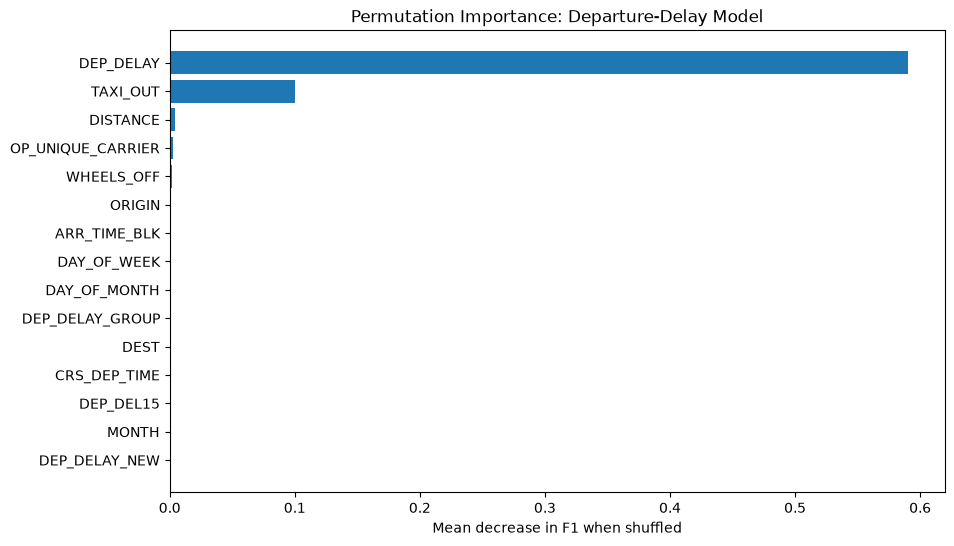

In [11]:
top_importance = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.xlabel("Mean decrease in F1 when shuffled")
plt.title("Permutation Importance: Departure-Delay Model")
plt.show()

In [12]:
dep_group_delay = (
    test_data
    .groupby("DEP_DELAY_GROUP")["ARR_DEL15"]
    .agg(["count", "mean"])
    .sort_index()
)

dep_group_delay["arrival_late_rate_percent"] = dep_group_delay["mean"] * 100

dep_group_delay

,count,mean,arrival_late_rate_percent
DEP_DELAY_GROUP,,,
-2.0,4696,0.011499,1.149915
-1.0,362040,0.033889,3.388852
0.0,112363,0.111425,11.142458
1.0,37572,0.479639,47.963909
2.0,20968,0.890834,89.083365
3.0,13216,0.988272,98.827179
4.0,9038,0.998562,99.856163
5.0,6684,0.999701,99.970078
6.0,5075,1.000000,100.000000


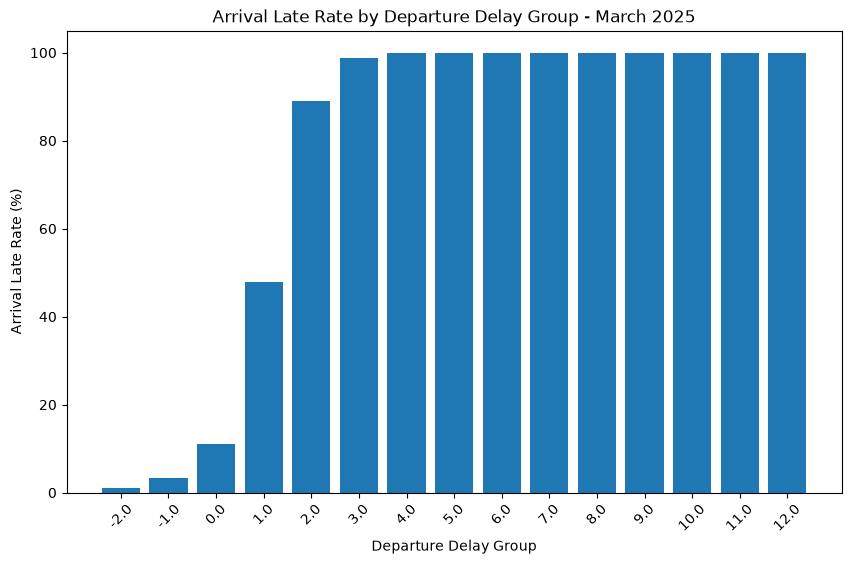

In [13]:
plot_data = dep_group_delay.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(plot_data["DEP_DELAY_GROUP"].astype(str), plot_data["arrival_late_rate_percent"])
plt.xlabel("Departure Delay Group")
plt.ylabel("Arrival Late Rate (%)")
plt.title("Arrival Late Rate by Departure Delay Group - March 2025")
plt.xticks(rotation=45)
plt.show()

In [14]:
test_with_probs = test_data.copy()
test_with_probs["predicted_delay_probability"] = test_probs

prob_by_dep_group = (
    test_with_probs
    .groupby("DEP_DELAY_GROUP")["predicted_delay_probability"]
    .agg(["count", "mean"])
    .sort_index()
)

prob_by_dep_group["mean_predicted_probability_percent"] = prob_by_dep_group["mean"] * 100

prob_by_dep_group

,count,mean,mean_predicted_probability_percent
DEP_DELAY_GROUP,,,
-2.0,4696,0.015579,1.557864
-1.0,362040,0.031467,3.146750
0.0,112363,0.096140,9.613982
1.0,37572,0.414513,41.451325
2.0,20968,0.848057,84.805743
3.0,13216,0.981803,98.180261
4.0,9038,0.997089,99.708943
5.0,6684,0.999334,99.933373
6.0,5075,0.999422,99.942161


In [15]:
actual_vs_predicted = dep_group_delay[["arrival_late_rate_percent"]].join(
    prob_by_dep_group[["mean_predicted_probability_percent"]]
)

actual_vs_predicted

,arrival_late_rate_percent,mean_predicted_probability_percent
DEP_DELAY_GROUP,,
-2.0,1.149915,1.557864
-1.0,3.388852,3.146750
0.0,11.142458,9.613982
1.0,47.963909,41.451325
2.0,89.083365,84.805743
3.0,98.827179,98.180261
4.0,99.856163,99.708943
5.0,99.970078,99.933373
6.0,100.000000,99.942161


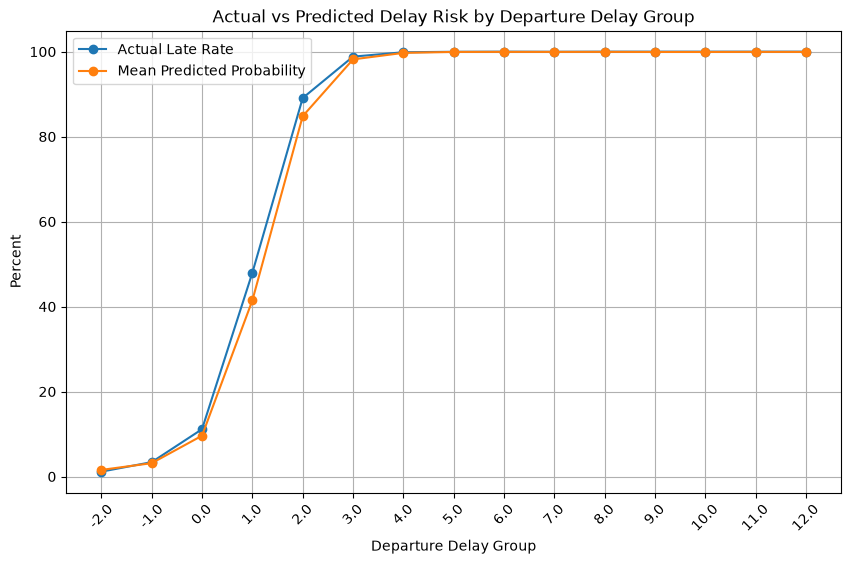

In [16]:
plot_data = actual_vs_predicted.reset_index()

plt.figure(figsize=(10, 6))
plt.plot(
    plot_data["DEP_DELAY_GROUP"].astype(str),
    plot_data["arrival_late_rate_percent"],
    marker="o",
    label="Actual Late Rate"
)
plt.plot(
    plot_data["DEP_DELAY_GROUP"].astype(str),
    plot_data["mean_predicted_probability_percent"],
    marker="o",
    label="Mean Predicted Probability"
)

plt.xlabel("Departure Delay Group")
plt.ylabel("Percent")
plt.title("Actual vs Predicted Delay Risk by Departure Delay Group")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [17]:
Path("../visuals").mkdir(exist_ok=True)

importance_df.to_csv(
    "../visuals/departure_model_permutation_importance.csv",
    index=False
)

dep_group_delay.to_csv(
    "../visuals/arrival_late_rate_by_departure_delay_group.csv"
)

actual_vs_predicted.to_csv(
    "../visuals/actual_vs_predicted_by_departure_delay_group.csv"
)

importance_df.head(15)

,feature,importance_mean,importance_std
7,DEP_DELAY,0.590152,0.004666
11,TAXI_OUT,0.100246,0.002994
5,DISTANCE,0.003831,0.000965
13,OP_UNIQUE_CARRIER,0.002453,0.000883
12,WHEELS_OFF,0.001806,0.000436
14,ORIGIN,0.001375,0.000412
17,ARR_TIME_BLK,0.000870,0.000248
2,DAY_OF_WEEK,0.000480,0.000295
1,DAY_OF_MONTH,0.000289,0.000083
10,DEP_DELAY_GROUP,0.000069,0.000151


The model interpretation confirms that departure delay is the dominant predictor of arrival delay. Permutation importance showed that `DEP_DELAY` caused by far the largest drop in F1-score when shuffled. `TAXI_OUT` was the second most important feature, while scheduled, route, airline, and airport features had much smaller effects.

The delay-rate analysis by `DEP_DELAY_GROUP` also supports this result. Flights that departed early or close to schedule had low arrival-delay rates, while flights with larger departure delays were very likely to arrive at least 15 minutes late. The model’s average predicted probabilities closely followed the actual arrival-delay rates across departure delay groups.

This shows that the departure-delay model performs well because it uses information available after departure, especially actual departure delay. In contrast, the scheduled-only model attempted to predict delays before departure and had much weaker future-month performance.